In [61]:
import pandas as pd

# Φόρτωση των αρχείων
imdb_df = pd.read_csv('IMDB top 1000.csv')
netflix_df = pd.read_csv('netflix_titles.csv')

# Δες τα ονόματα των στηλών
print("IMDb Columns:", imdb_df.columns)
print("Netflix Columns:", netflix_df.columns)

IMDb Columns: Index(['Unnamed: 0', 'Title', 'Certificate', 'Duration', 'Genre', 'Rate',
       'Metascore', 'Description', 'Cast', 'Info'],
      dtype='object')
Netflix Columns: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [62]:
import re

# 1. Καθαρισμός IMDb:
# Αφαιρεί την αρίθμηση στην αρχή (π.χ. "1. ")
# ΚΑΙ τη χρονιά στην παρένθεση στο τέλος (π.χ. " (1994)")
imdb_df['clean_title'] = imdb_df['Title'].str.replace(r'^\d+\.\s+', '', regex=True) # Βγάζει το "1. "
imdb_df['clean_title'] = imdb_df['clean_title'].str.replace(r'\s\(\d{4}\)$', '', regex=True) # Βγάζει το "(1994)"
imdb_df['clean_title'] = imdb_df['clean_title'].str.lower().str.strip()

# 2. Καθαρισμός Netflix
netflix_df['clean_title'] = netflix_df['title'].str.lower().str.strip()

# 3. Merge
merged_df = pd.merge(imdb_df, netflix_df[netflix_df['type'] == 'Movie'], on='clean_title', how='inner')

print(f"Found {len(merged_df)} movies in common.")

Found 206 movies in common.


In [63]:
# 1. Εξαγωγή έτους από το IMDb (από την παρένθεση στο τέλος του Title)
imdb_df['year'] = imdb_df['Title'].str.extract(r'\((\d{4})\)').astype(float)

# 2. Δημιουργία Δεκαετιών (π.χ. 1994 -> 1990s)
imdb_df['decade'] = (imdb_df['year'] // 10 * 10).astype(int).astype(str) + 's'
merged_df['decade'] = (merged_df['release_year'] // 10 * 10).astype(int).astype(str) + 's'

# 3. Υπολογισμός κατανομής
total_distribution = imdb_df['decade'].value_counts().sort_index()
netflix_distribution = merged_df['decade'].value_counts().sort_index()

# 4. Δημιουργία τελικού πίνακα σύγκρισης
comparison_table = pd.DataFrame({
    'IMDb Top 1000': total_distribution,
    'Found on Netflix': netflix_distribution
}).fillna(0).astype(int)

# 5. Υπολογισμός ποσοστού κάλυψης (%)
comparison_table['Coverage %'] = (comparison_table['Found on Netflix'] / comparison_table['IMDb Top 1000'] * 100).round(1)

print(comparison_table)

        IMDb Top 1000  Found on Netflix  Coverage %
decade                                             
1920s              39                 0         0.0
1930s              31                 0         0.0
1940s              43                 0         0.0
1950s              66                 0         0.0
1960s              26                 2         7.7
1970s              24                 5        20.8
1980s              31                 4        12.9
1990s             167                23        13.8
2000s             282                70        24.8
2010s             290                94        32.4
2020s               1                 8       800.0


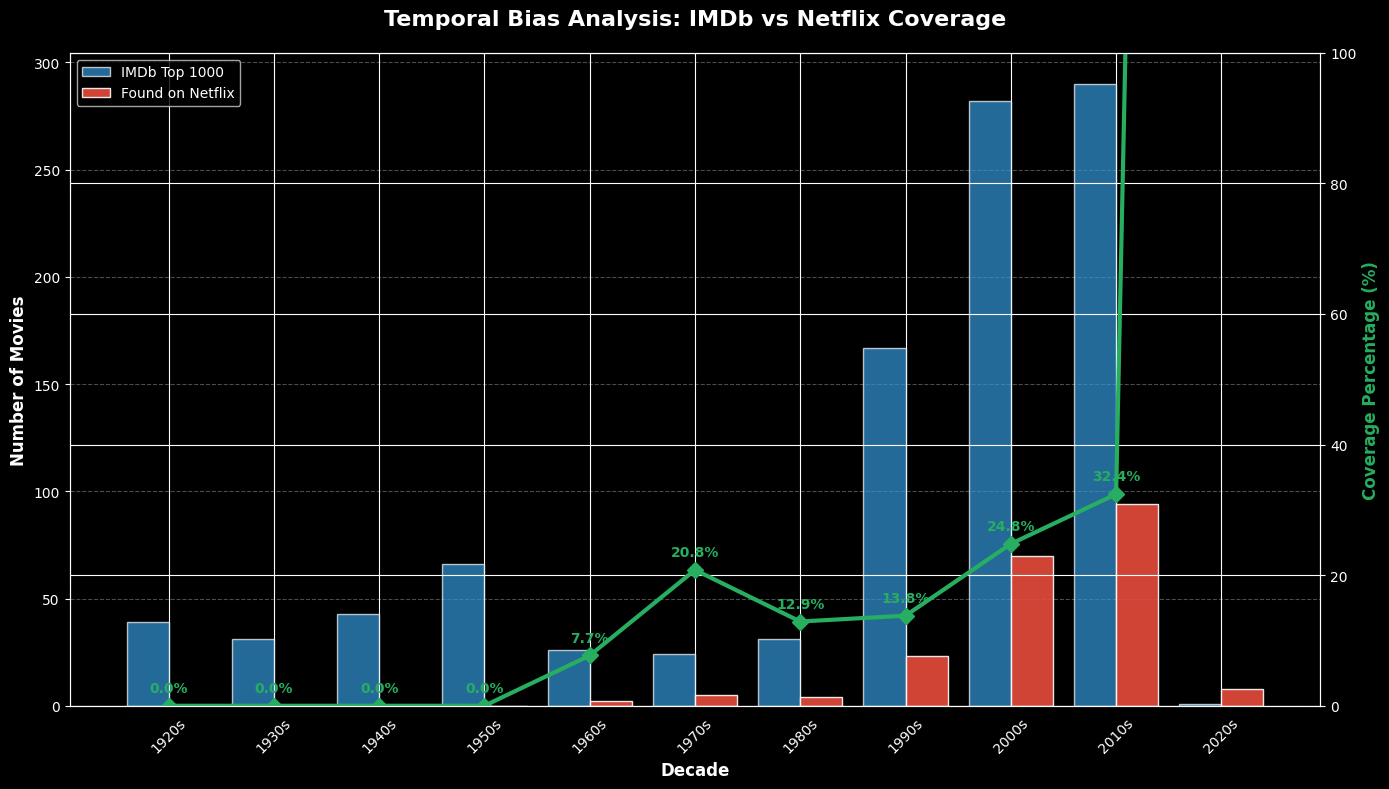

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Prepare & Sort Data (Ensure decades are in chronological order)
sorted_decades = sorted(comparison_table.index, key=lambda x: int(x[:-1]))
comparison_table.index = pd.Categorical(comparison_table.index, categories=sorted_decades, ordered=True)
df_plot = comparison_table.sort_index()

# 2. Convert to numpy arrays for clean plotting
labels = df_plot.index.astype(str)
imdb_vals = df_plot['IMDb Top 1000'].values
netflix_vals = df_plot['Found on Netflix'].values
coverage_vals = df_plot['Coverage %'].values

x = np.arange(len(labels))
width = 0.4

fig, ax1 = plt.subplots(figsize=(14, 8))

# 3. Create Grouped Bars
ax1.bar(x - width/2, imdb_vals, width, label='IMDb Top 1000', color='#3498db', alpha=0.7)
ax1.bar(x + width/2, netflix_vals, width, label='Found on Netflix', color='#e74c3c', alpha=0.9)

# Axis 1 Settings (Quantities)
ax1.set_xlabel('Decade', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Movies', fontsize=12, fontweight='bold')
ax1.set_title('Temporal Bias Analysis: IMDb vs Netflix Coverage', fontsize=16, pad=20, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45)
ax1.legend(loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# 4. Axis 2 for Coverage % (Line Chart)
ax2 = ax1.twinx()
ax2.plot(x, coverage_vals, color='#27ae60', marker='D', markersize=8, linewidth=3, label='Coverage %')
ax2.set_ylabel('Coverage Percentage (%)', color='#27ae60', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 100)

# Add percentage labels above points
for i, val in enumerate(coverage_vals):
    ax2.annotate(f'{val}%', (x[i], val), xytext=(0, 10),
                 textcoords='offset points', ha='center', color='#27ae60', fontweight='bold')

fig.tight_layout()
plt.show()